# 04 - Mohamed's Model Training

Fused 14-feature transformer (with optional LSTM branch on the 6 price
features) over a 20-day window. Same train/val/test split, same loss, same
optimizer family as the baseline so any performance delta is attributable
to the added sentiment features.


In [1]:
import sys, time, platform
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, torch
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 110

from src import data_loader as dl, train as tr
from src.mohamed_model import MohamedModel
from src.data_loader import MODELS_DIR, PLOTS_DIR, SEED
from src.train import TrainConfig

MODELS_DIR.mkdir(parents=True, exist_ok=True); PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print('Python :', platform.python_version(), '| torch:', torch.__version__,
      '| CUDA:', torch.cuda.is_available())


Python : 3.14.3 | torch: 2.11.0+cpu | CUDA: False


## 1. Data

In [2]:
ds = dl.assemble_dataset(use_sentiment=True, window=20)
print('train:', ds['X_train'].shape, ds['y_train'].shape)
print('val  :', ds['X_val'].shape,   ds['y_val'].shape)
print('test :', ds['X_test'].shape,  ds['y_test'].shape)
print('features:', ds['feature_names'])


train: (4353, 20, 14) (4353, 3)
val  : (943, 20, 14) (943, 3)
test : (939, 20, 14) (939, 3)
features: ['Open', 'High', 'Low', 'Close', 'Volume', 'MACD', 'finbert_positive', 'finbert_negative', 'finbert_neutral', 'finbert_confidence', 'headline_count', 'no_news_flag', 'net_sentiment_ma3', 'net_sentiment_ma7']


## 2. Model + config

In [3]:
tr.set_seed(SEED)
import warnings
warnings.filterwarnings('ignore', message='enable_nested_tensor.*')
model = MohamedModel(n_features=14, n_price_features=6, seq_len=20,
                     d_model=128, n_heads=4, ffn_dim=256, n_layers=2,
                     dropout=0.1, lstm_hidden=64, use_lstm_branch=True)
n_params = sum(p.numel() for p in model.parameters())
print(f'Mohamed params: {n_params:,}')
print(model)


Mohamed params: 322,819
MohamedModel(
  (proj): Linear(in_features=14, out_features=128, bias=True)
  (proj_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (proj_drop): Dropout(p=0.1, inplace=False)
  (pos_enc): SinusoidalPositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (lstm): LSTM(6, 64, batch_first=Tru

In [4]:
cfg = TrainConfig(epochs=60, batch_size=64, lr=5e-4, weight_decay=1e-5,
                  grad_clip=1.0, early_stopping_patience=8, seed=SEED)
print(cfg)


TrainConfig(epochs=60, batch_size=64, lr=0.0005, weight_decay=1e-05, grad_clip=1.0, early_stopping_patience=8, seed=42)


## 3. Train

In [5]:
save_path = MODELS_DIR / 'mohamed.pt'
log_rows = []

def on_epoch(epoch, tloss, vloss, dt, improved):
    flag = '<-- best' if improved else ''
    print(f'epoch {epoch:>3} | train MSE {tloss:.6f} | val MSE {vloss:.6f}'
          f' | {dt:5.1f}s {flag}')
    log_rows.append({'epoch': epoch, 'train_loss': tloss, 'val_loss': vloss, 'seconds': dt})

history = tr.train_model(model, ds['X_train'], ds['y_train'],
                         ds['X_val'], ds['y_val'],
                         cfg, save_path, on_epoch_end=on_epoch)
print(f'Done in {history.total_seconds:.1f}s; best val MSE {history.best_val_loss:.6f}'
      f' at epoch {history.best_epoch}/{len(history.train_loss)}.')


epoch   1 | train MSE 0.007185 | val MSE 0.000862 |   3.1s <-- best


epoch   2 | train MSE 0.001871 | val MSE 0.000728 |   4.1s <-- best


epoch   3 | train MSE 0.001476 | val MSE 0.000894 |   3.4s 


epoch   4 | train MSE 0.001320 | val MSE 0.000991 |   3.7s 


epoch   5 | train MSE 0.001166 | val MSE 0.000701 |   3.4s <-- best


...

epoch  21 | train MSE 0.000911 | val MSE 0.000750 |   3.4s 


epoch  22 | train MSE 0.000926 | val MSE 0.000710 |   3.4s 


epoch  23 | train MSE 0.000875 | val MSE 0.000763 |   3.2s 


epoch  24 | train MSE 0.000937 | val MSE 0.000703 |   3.4s 


epoch  25 | train MSE 0.000852 | val MSE 0.000637 |   3.6s 
Done in 85.8s; best val MSE 0.000606 at epoch 17/25.


## 4. Loss curves

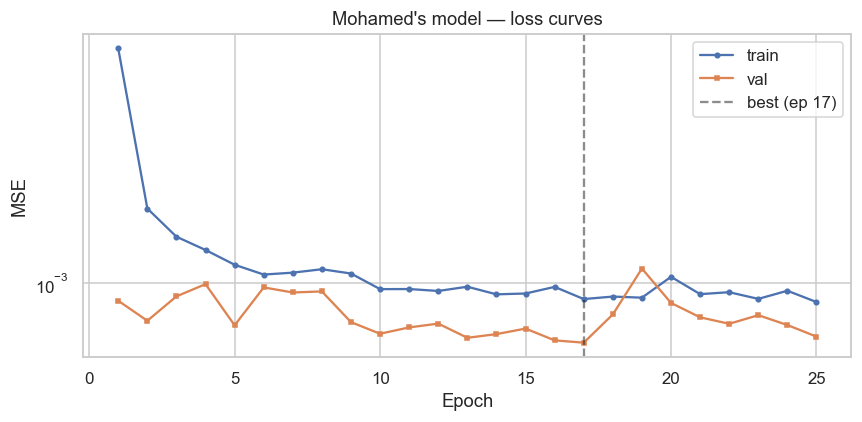

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs = np.arange(1, len(history.train_loss) + 1)
ax.plot(epochs, history.train_loss, label='train', marker='o', ms=3)
ax.plot(epochs, history.val_loss, label='val', marker='s', ms=3)
ax.axvline(history.best_epoch, color='k', ls='--', alpha=0.5, label=f'best (ep {history.best_epoch})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.set_title("Mohamed's model - loss curves")
ax.set_yscale('log'); ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / '04_mohamed_loss_curves.png', dpi=150)
plt.show()


In [7]:
log = pd.DataFrame(log_rows)
log.to_csv(dl.PROJECT_ROOT / 'results' / 'mohamed_train_log.csv', index=False)
log.tail()


,epoch,train_loss,val_loss,seconds
20,21,0.000911,0.000750,3.405068
21,22,0.000926,0.000710,3.441057
22,23,0.000875,0.000763,3.204011
23,24,0.000937,0.000703,3.437803
24,25,0.000852,0.000637,3.621799


**Summary:** Mohamed's transformer trained on the 14-feature daily block.
Best checkpoint saved to `results/models/mohamed.pt`.
